In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
summary_df = pd.read_csv('../data/vessel_summary.csv')
cmp_df = pd.read_csv('../data/flag_change_intervals.csv')
identities_df = pd.read_csv('../data/identities.csv')
flags_df = pd.read_csv('../data/flag_df.csv')

#### Visualization of the frequency of flag changes up to 2023 and thereafter

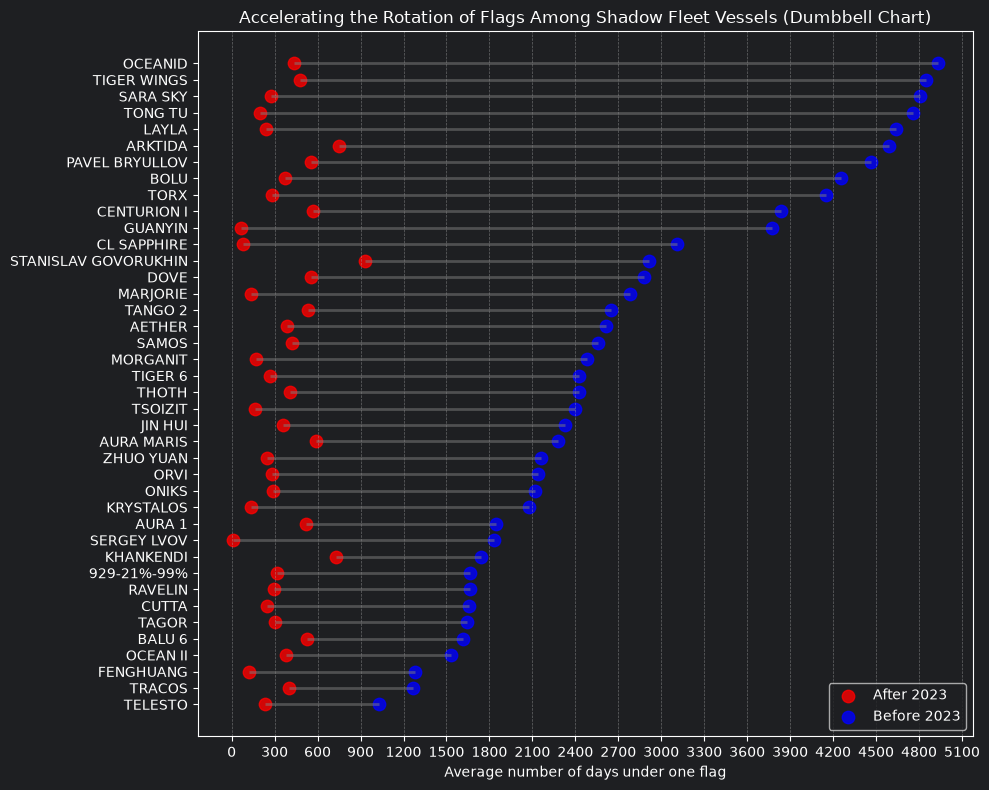

In [2]:

df = identities_df.copy()
df['transmission_from'] = pd.to_datetime(
    df['transmission_from'], format='mixed', utc=True
)
df['transmission_to'] = pd.to_datetime(
    df['transmission_to'], format='mixed', utc=True
)
# If transmission_to is null, use the current date (or data export date)
df['transmission_to'] = df['transmission_to'].fillna(pd.Timestamp.now(tz='UTC'))
df['duration_days'] = (df['transmission_to'] - df['transmission_from']).dt.days

# 2. Split into periods (before 2023 and after)
df['period'] = df['transmission_from'].apply(
    lambda x: 'before_2023' if x.year < 2023 else 'after_2023'
)

# 3. Calculate average flag ownership duration per IMO for each period
grouped = df.groupby(['imo', 'period'])['duration_days'].mean().unstack()

# Keep only vessels with data for both periods and reset index to keep IMO as a column
plot_data = grouped.dropna().reset_index()

plot_data = plot_data.merge(summary_df[['imo', 'current_name']], on='imo')

plt.figure(figsize=(10, 8))
# Sort by "before_2023" duration for visual clarity
plot_data = plot_data.sort_values('before_2023')

plt.hlines(
    y=plot_data['current_name'],
    xmin=plot_data['after_2023'],
    xmax=plot_data['before_2023'],
    color='grey',
    alpha=0.5,
    linewidth=2,
)

# Draw points
plt.scatter(
    plot_data['after_2023'],
    plot_data['current_name'],
    color='red',
    alpha=0.8,
    label='After 2023',
    s=80,
)
plt.scatter(
    plot_data['before_2023'],
    plot_data['current_name'],
    color='blue',
    alpha=0.8,
    label='Before 2023',
    s=80,
)
plt.xticks(np.arange(0, plot_data['before_2023'].max() + 300, 300))
plt.legend()
plt.xlabel('Average number of days under one flag')
plt.title(
    'Accelerating the Rotation of Flags Among Shadow Fleet Vessels (Dumbbell Chart)'
)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

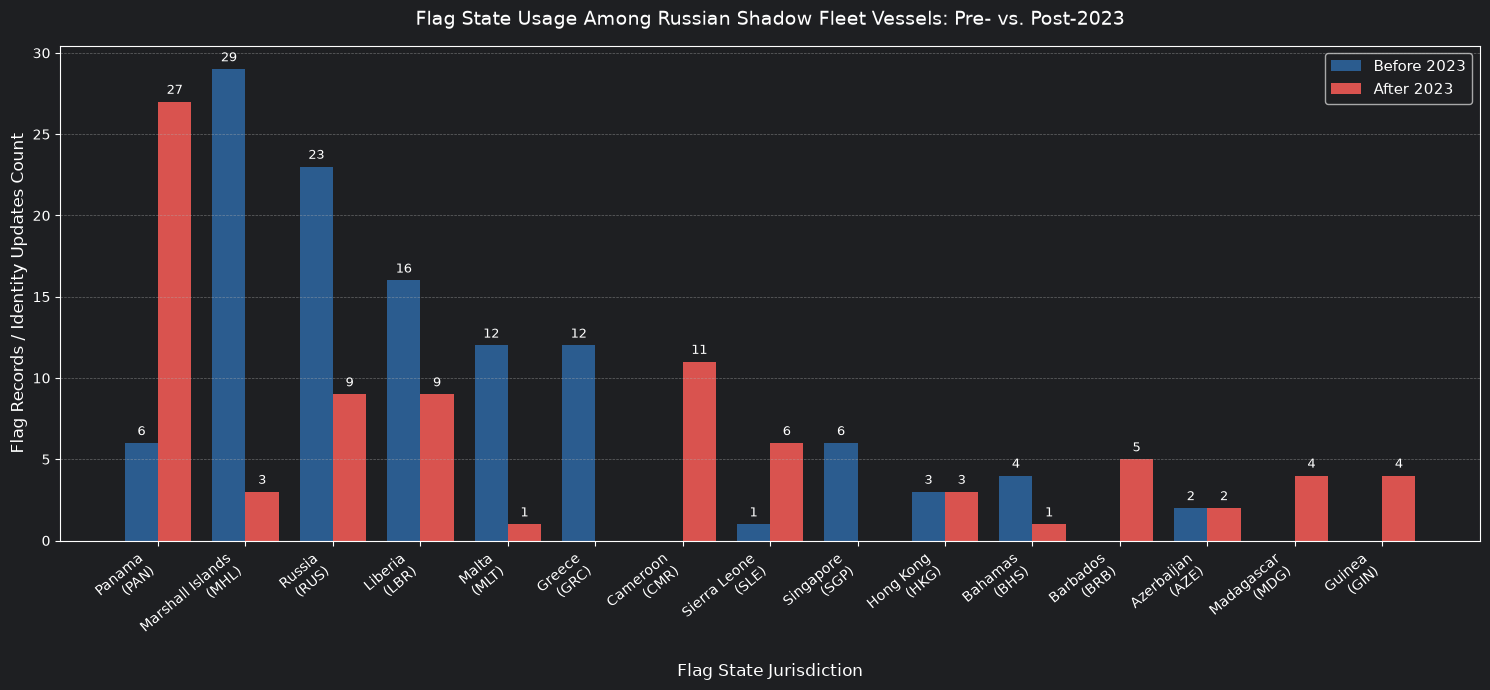

In [5]:
# Parse datetime and filter out records with missing flags
identities_df['transmission_from'] = pd.to_datetime(
    identities_df['transmission_from'], format='mixed', utc=True
)
df_flags = identities_df.dropna(subset=['flag']).copy()

df_flags['period'] = df_flags['transmission_from'].apply(
    lambda x: 'Before 2023' if x.year < 2023 else 'After 2023'
)

flag_counts = df_flags.groupby(['flag', 'period']).size().unstack(fill_value=0)
flag_counts['total'] = flag_counts['Before 2023'] + flag_counts['After 2023']


top_flags = flag_counts.sort_values(by='total', ascending=False).head(15)


iso_to_country = {
    'PAN': 'Panama',
    'MHL': 'Marshall Islands',
    'RUS': 'Russia',
    'LBR': 'Liberia',
    'CMR': 'Cameroon',
    'MLT': 'Malta',
    'SLE': 'Sierra Leone',
    'BRB': 'Barbados',
    'GRC': 'Greece',
    'MDG': 'Madagascar',
    'HKG': 'Hong Kong',
    'SGP': 'Singapore',
    'PLW': 'Palau',
    'BHS': 'Bahamas',
    'GIN': 'Guinea',
    'COM': 'Comoros',
    'NIC': 'Nicaragua',
    'CHN': 'China',
    'AZE': 'Azerbaijan',
    'DEU': 'Germany',
    'TUR': 'Turkey',
    'GNQ': 'Equatorial Guinea',
    'COK': 'Cook Islands',
    'SYR': 'Syria',
    'ITA': 'Italy',
    'SAU': 'Saudi Arabia',
    'BES': 'Caribbean Netherlands',
    'ATG': 'Antigua and Barbuda',
    'CYP': 'Cyprus',
    'CYM': 'Cayman Islands',
    'FRA': 'France',
    'ESP': 'Spain',
    'DNK': 'Denmark',
    'KWT': 'Kuwait',
    'IMN': 'Isle of Man',
    'VUT': 'Vanuatu',
    'SMR': 'San Marino',
    'MOZ': 'Mozambique',
    'CAN': 'Canada',
}

top_flags['label'] = top_flags.index.map(
    lambda x: f'{iso_to_country.get(x, x)}\n({x})'
)


plt.figure(figsize=(15, 7))
x = np.arange(len(top_flags))
width = 0.38

bars_before = plt.bar(
    x - width / 2,
    top_flags['Before 2023'],
    width,
    label='Before 2023',
    color='#2b5c8f',
)
bars_after = plt.bar(
    x + width / 2,
    top_flags['After 2023'],
    width,
    label='After 2023',
    color='#d9534f',
)

plt.xlabel('Flag State Jurisdiction', fontsize=12, labelpad=10)
plt.ylabel('Flag Records / Identity Updates Count', fontsize=12)
plt.title(
    'Flag State Usage Among Russian Shadow Fleet Vessels: Pre- vs. Post-2023',
    fontsize=14,
    pad=15,
)
plt.xticks(x, top_flags['label'], rotation=40, ha='right', fontsize=10)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add numerical value annotations above bars
for bar in bars_before:
  h = bar.get_height()
  if h > 0:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.3,
        int(h),
        ha='center',
        va='bottom',
        fontsize=9,
    )

for bar in bars_after:
  h = bar.get_height()
  if h > 0:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.3,
        int(h),
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.show()